In [128]:
#Import libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib


In [129]:
#Read cleaned data file
df = pd.read_csv("../../data/processed/Customers.csv")

In [130]:
# Select features for segmentation
features = ["annual_income", "spending_score"]
X = df[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

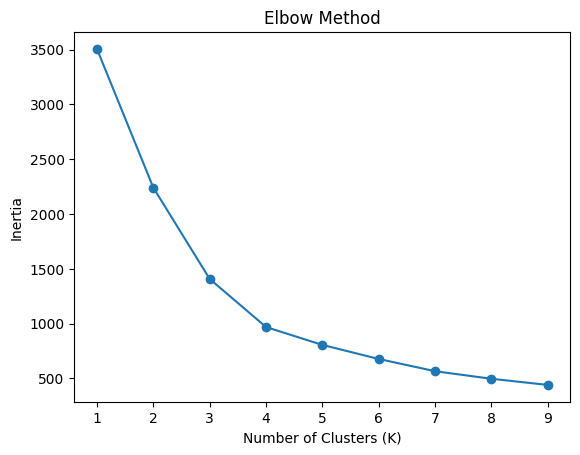

In [ ]:
#Find optimal K using KMeans clustering
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.savefig("../../reports/Elbow.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#Use Silhouette score to measure how well each data point fits within its assigned cluster compared to other clusters.

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3394
K = 3, Silhouette Score = 0.3743
K = 4, Silhouette Score = 0.3801
K = 5, Silhouette Score = 0.3699
K = 6, Silhouette Score = 0.3745
K = 7, Silhouette Score = 0.3725
K = 8, Silhouette Score = 0.3595


In [ ]:
#Fit model using k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster1"] = kmeans.fit_predict(X_scaled)

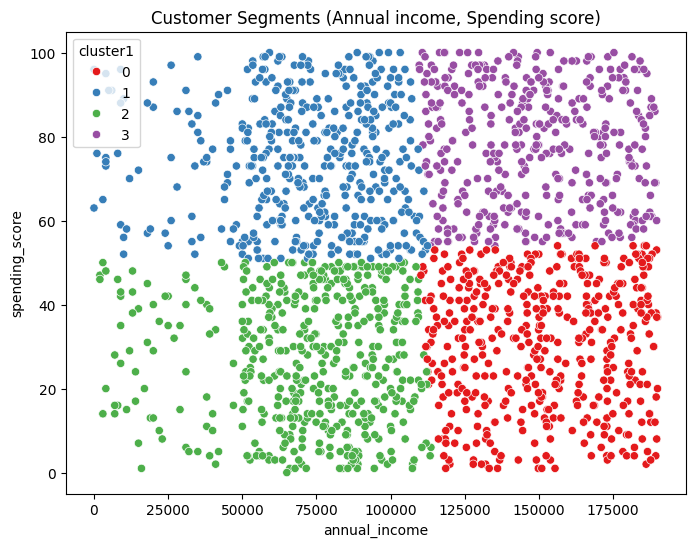

In [134]:
#Cluster visual
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="annual_income",
    y="spending_score",
    hue="cluster1",
    palette="Set1",
    data=df
)
plt.title("Customer Segments (Annual income, Spending score)")
plt.savefig("../../reports/Income_Spending_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

This cluster shows Spending is not driven by Income
1. High Income and High Spending (Red)
2. High Income and Low Spending (Blue)
3. Moderate Income and High Spendign (Green)
4. Moderate Income and Low Spending (Purple)



In [135]:
#Pipeline for Income vs Spending
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=42))
])

pipeline.fit(X)

cluster_labels = {
    0: "High Income and High Spending (Red)",
    1: "High Income and Low Spending (Blue)",
    2: "Moderate Income and High Spending (Green)",
    3: "Moderate Income and Low Spending (Purple)"
}

artifact = {
    "model_name": "Income vs Spending (k=4)",
    "features": features,
    "pipeline": pipeline,
    "cluster_labels": cluster_labels,
    "cluster_note": "This cluster shows spending is not driven by income."
}

joblib.dump(artifact, "../../models/kmeans_income_spend.joblib")

['../../models/kmeans_income_spend.joblib']

##KMeans clustering using age and spendig score

In [136]:
#Compute silhouette score for KMeans clustering using age and spendig score
from sklearn.metrics import silhouette_score

features = ["age", "spending_score"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3547
K = 3, Silhouette Score = 0.3505
K = 4, Silhouette Score = 0.3949
K = 5, Silhouette Score = 0.3979
K = 6, Silhouette Score = 0.3685
K = 7, Silhouette Score = 0.3851
K = 8, Silhouette Score = 0.3805


In [137]:
#Fit model using k=4 since it is the best score
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster2"] = kmeans.fit_predict(X_scaled)

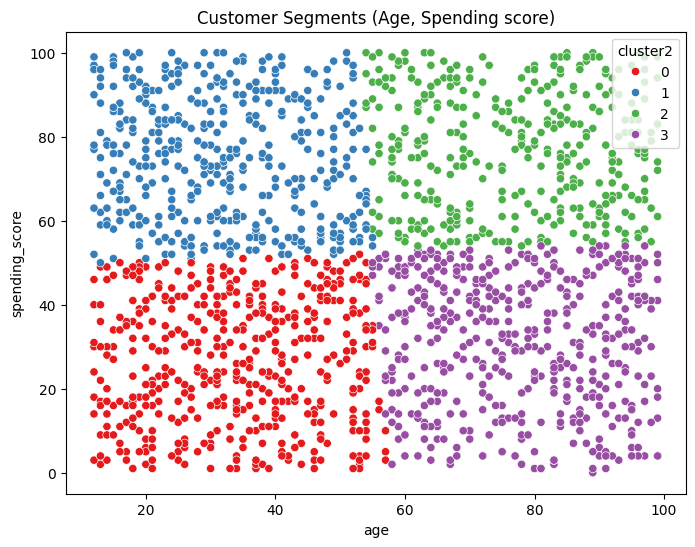

In [138]:
#Visualizing cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="age",
    y="spending_score",
    hue="cluster2",
    palette="Set1",
    data=df
)
plt.title("Customer Segments (Age, Spending score)")
plt.savefig("../../reports/Age_Spending_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

This cluster shows Spending is not driven by Age alone.
1. High Age and High Spending (Red)
2. High Age and Low Spending (Blue)
3. Low Age and Low Spending (Green)
4. Low Age and High Spending (Purple)


In [139]:
#Pipeline for Age vs Spending score
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=42))
])

pipeline.fit(X)

cluster_labels = {
    0: "High Age and High Spending (Red)",
    1: "High Age and Low Spending (Blue)",
    2: "Low Age and Low Spending (Green)",
    3: "Low Age and High Spending (Purple)"
}

artifact = {
    "model_name": "Age vs Spending (k=4)",
    "features": features,
    "pipeline": pipeline,
    "cluster_labels": cluster_labels,
    "cluster_note": "This cluster shows Spending is not driven by Age alone."
}

joblib.dump(artifact, "../../models/kmeans_age_spend.joblib")

['../../models/kmeans_age_spend.joblib']

In [140]:
#Compute silhouette score for KMeans clustering using family size and spendig score
from sklearn.metrics import silhouette_score

X = df[["family_size", "spending_score"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3377
K = 3, Silhouette Score = 0.3879
K = 4, Silhouette Score = 0.3921
K = 5, Silhouette Score = 0.3769
K = 6, Silhouette Score = 0.3947
K = 7, Silhouette Score = 0.3894
K = 8, Silhouette Score = 0.3841


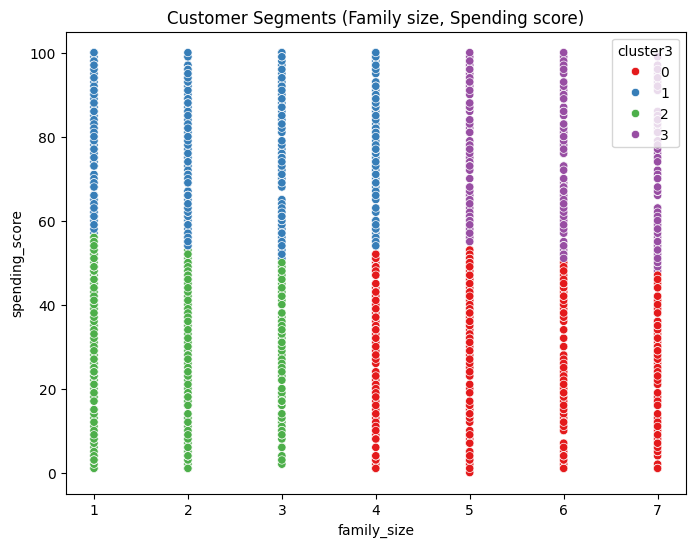

In [141]:
#Fit model using k=4 since it is the best score
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster3"] = kmeans.fit_predict(X_scaled)

#Visualizing cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="family_size",
    y="spending_score",
    hue="cluster3",
    palette="Set1",
    data=df
)
plt.title("Customer Segments (Family size, Spending score)")
plt.savefig("../../reports/Familysize_Spending_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

No clear realtionship between family size and spending.

In [142]:
#Segment analysis by combining input features Age and annual income with spending score
X = df[["age", "annual_income", "spending_score"]]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [143]:
#Use 4 clusters to fit model
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster4"] = kmeans.fit_predict(X_scaled)

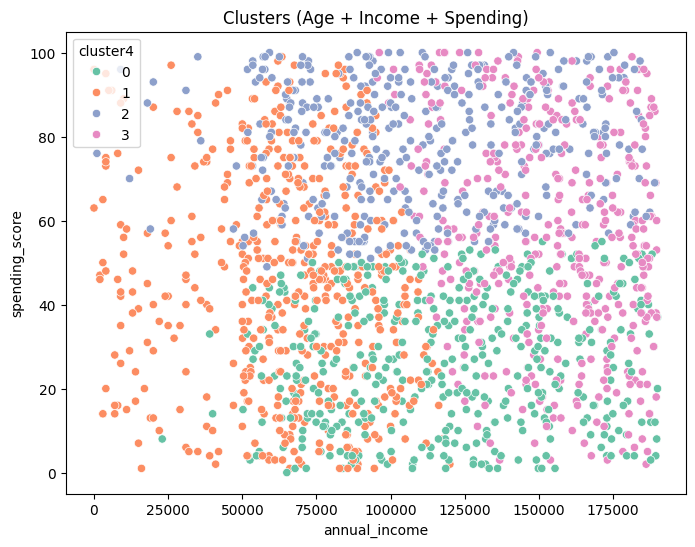

In [144]:
#visualize cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="annual_income",
    y="spending_score",
    hue="cluster4",
    palette="Set2",
    data=df
)
plt.title("Clusters (Age + Income + Spending)")
plt.savefig("../../reports/Age_Income_Spending_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

##After combining age with annual income clusters don't show clear separation like before. So combining features does not create any additional strength.

In [145]:
#Building a pipeline for categorical input gender to see any pattern
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["spending_score"]),
        ("cat", OneHotEncoder(), ["gender"])
    ]
)

kmeans_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("kmeans", KMeans(n_clusters=4, random_state=42))
])
df["cluster5"] = kmeans_pipe.fit_predict(df)

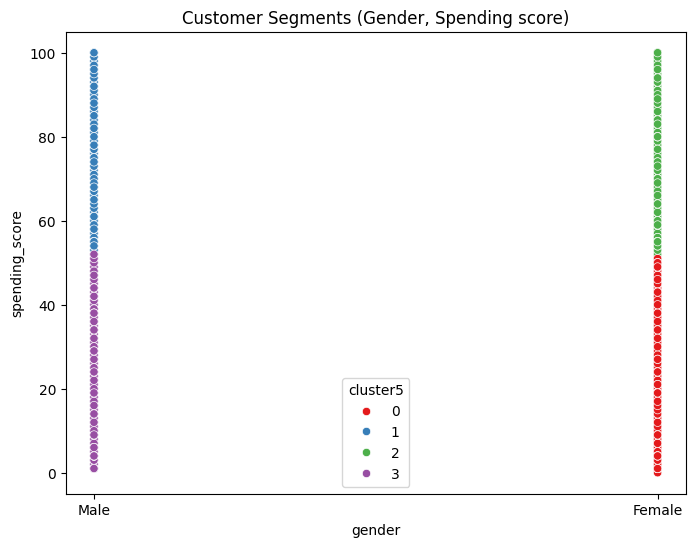

In [146]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="gender",
    y="spending_score",
    hue="cluster5",
    palette="Set1",
    data=df
)
plt.title("Customer Segments (Gender, Spending score)")
plt.savefig("../../reports/Gender_Spending_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

##High value customers identification 

In [147]:
df["high_value"] = (df["spending_score"] >= 70).astype(int)
features = ["age","annual_income","family_size","work_experience"]
X = df[features].copy()
y = df["high_value"]

In [148]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

model = RandomForestClassifier()
model.fit(X_train,y_train)

df["prob_high_spender"] = model.predict_proba(X)[:,1]

In [149]:
df[df["prob_high_spender"] > 0.7][
    ["CustomerID","prob_high_spender"]
]

,CustomerID,prob_high_spender
1,2,0.73
3,4,0.85
5,6,0.74
9,10,0.79
11,12,0.86
...,...,...
1735,1979,0.78
1740,1988,0.82
1741,1989,0.71
1746,1994,0.74


In [150]:
df.sort_values("prob_high_spender", ascending=False)[
    ["CustomerID","prob_high_spender"]
].head(5)

,CustomerID,prob_high_spender
153,158,0.94
308,327,0.93
1134,1286,0.92
354,377,0.92
1004,1134,0.91


In [151]:
#Building a pipeline for highvalue customers

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

artifact = {
    "model_name": "High Value Predictor (RF, p>=threshold)",
    "features": features,
    "pipeline": pipeline,
    "positive_class": 1
}

joblib.dump(artifact, "../../models/rf_high_value.joblib")

['../../models/rf_high_value.joblib']